# Tuning circles, polygons, and cycloids

A pitch-class or ratio set wraps onto a circle exactly once per equave, and
the resulting layout exposes interval structure at a glance. This notebook
reproduces the circular/polygonal figures from the report — tuning circles,
star polygons, times-table circles, and the rose / cycloid families.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


## Star polygons

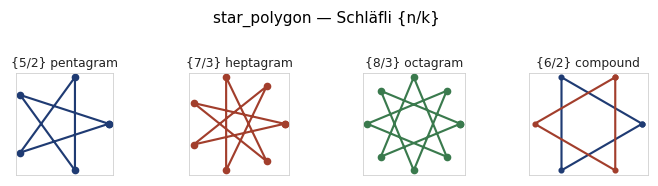

In [2]:
from biotuner.harmonic_geometry import star_polygon

cases = [(5, 2, "{5/2} pentagram"),
         (7, 3, "{7/3} heptagram"),
         (8, 3, "{8/3} octagram"),
         (6, 2, "{6/2} compound")]
geoms  = [star_polygon(n, k, radius=1.0) for n, k, _ in cases]
titles = [lab for _, _, lab in cases]
plotting.gallery(geoms, titles=titles, n_cols=4,
                 suptitle="star_polygon — Schläfli {n/k}");


## Times-table circles

Connect point `k` on a circle to point `k × m mod n`. Distinct integer
multipliers carve out cardioid / nephroid / epicycloid envelopes.

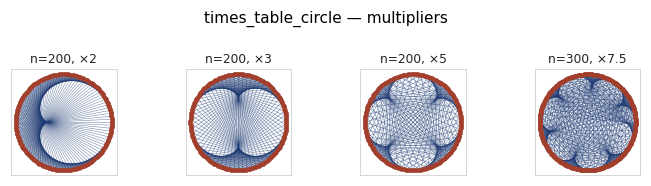

In [3]:
from biotuner.harmonic_geometry import times_table_circle

cases = [(200, 2), (200, 3), (200, 5), (300, 7.5)]
geoms  = [times_table_circle(n_points=n, multiplier=m, radius=1.0) for n, m in cases]
titles = [f"n={n}, ×{m}" for n, m in cases]
plotting.gallery(geoms, titles=titles, n_cols=4,
                 suptitle="times_table_circle — multipliers");


## Tuning circle

A 7-note just-intonation diatonic mapped onto a circle, with point size
encoding amplitude.

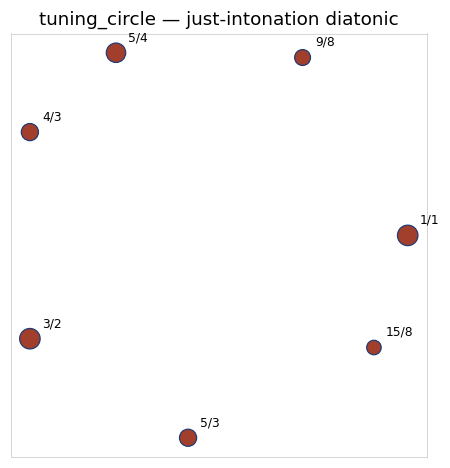

In [4]:
from biotuner.harmonic_geometry import tuning_circle

inp = HarmonicInput(
    ratios=[Fraction(1, 1), Fraction(9, 8), Fraction(5, 4), Fraction(4, 3),
            Fraction(3, 2), Fraction(5, 3), Fraction(15, 8)],
    amplitudes=[1.0, 0.6, 0.9, 0.7, 1.0, 0.7, 0.5],
)
g = tuning_circle(inp, radius=1.0)
fig, ax = plotting.plot_geometry(g)
coords = np.asarray(g.coordinates)
for (x, y), lab in zip(coords, ["1/1", "9/8", "5/4", "4/3",
                                 "3/2", "5/3", "15/8"]):
    ax.annotate(lab, (x, y), xytext=(8, 8), textcoords="offset points",
                fontsize=8)
ax.set_title("tuning_circle — just-intonation diatonic");


## Rose curves

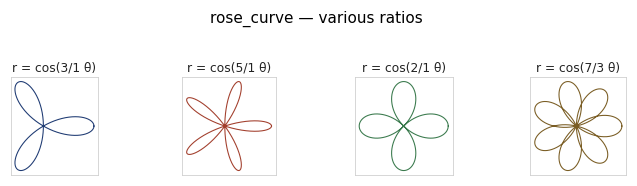

In [5]:
from biotuner.harmonic_geometry import rose_curve

cases = [Fraction(3, 1), Fraction(5, 1), Fraction(2, 1), Fraction(7, 3)]
geoms  = [rose_curve(r, n_points=2000) for r in cases]
titles = [f"r = cos({r.numerator}/{r.denominator} θ)" for r in cases]
plotting.gallery(geoms, titles=titles, n_cols=4, draw_kwargs={"lw": 0.7},
                 suptitle="rose_curve — various ratios");


## Epicycloid / hypocycloid

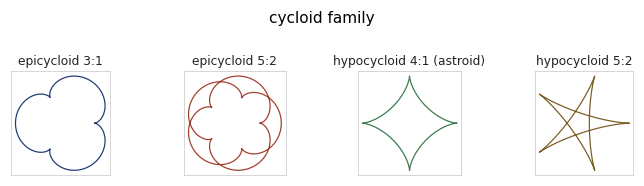

In [6]:
from biotuner.harmonic_geometry import epicycloid, hypocycloid

cases = [
    (epicycloid, Fraction(3, 1), "epicycloid 3:1"),
    (epicycloid, Fraction(5, 2), "epicycloid 5:2"),
    (hypocycloid, Fraction(4, 1), "hypocycloid 4:1 (astroid)"),
    (hypocycloid, Fraction(5, 2), "hypocycloid 5:2"),
]
geoms = [fn(r, n_points=2000) for fn, r, _ in cases]
plotting.gallery(geoms, titles=[lab for _, _, lab in cases], n_cols=4,
                 draw_kwargs={"lw": 0.8},
                 suptitle="cycloid family");
